Dataset Shape: (4269, 13)

Columns:
Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

First 5 Records:
   loan_id  no_of_dependents      education self_employed  income_annum  \
0        1                 2       Graduate            No       9600000   
1        2                 0   Not Graduate           Yes       4100000   
2        3                 3       Graduate            No       9100000   
3        4                 3       Graduate            No       8200000   
4        5                 5   Not Graduate           Yes       9800000   

   loan_amount  loan_term  cibil_score  residential_assets_value  \
0     29900000         12          778                   2400000   
1     12200000          8          417                   2700000   
2     2

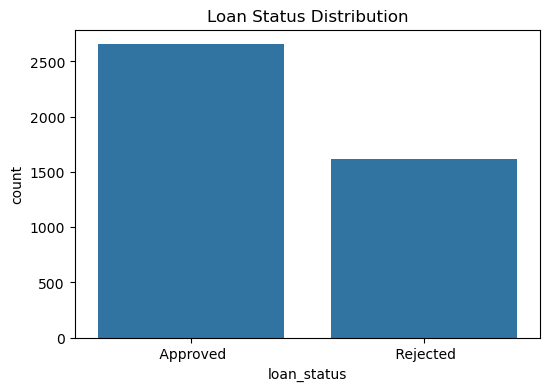

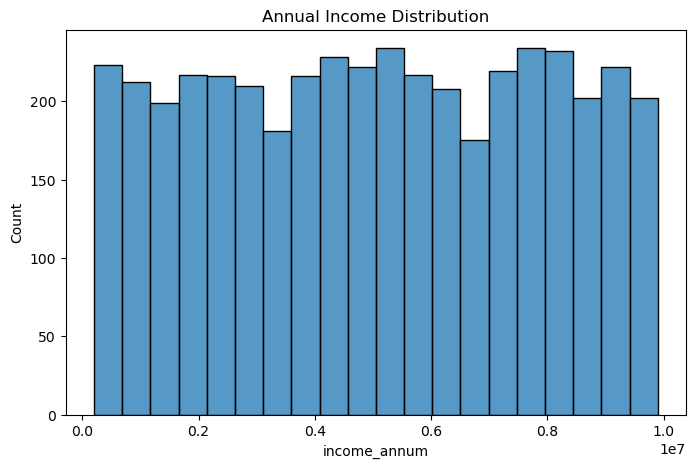

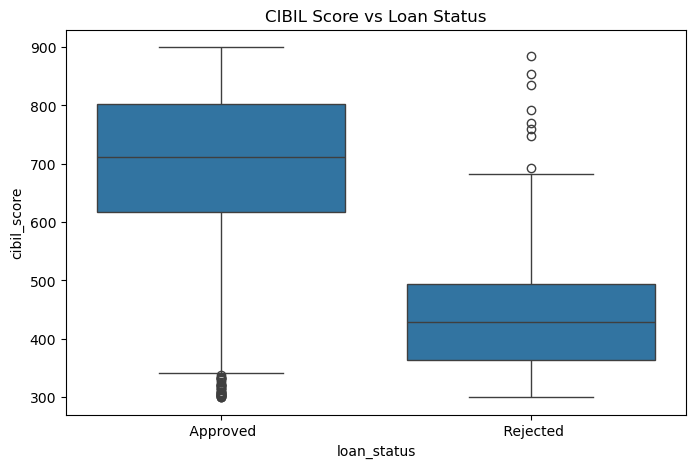

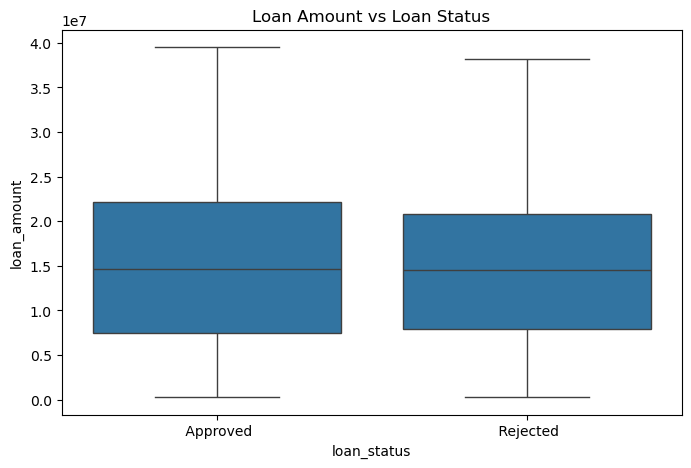


===== Logistic Regression =====
Accuracy: 0.7985948477751756

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.91      0.85       536
           1       0.80      0.61      0.69       318

    accuracy                           0.80       854
   macro avg       0.80      0.76      0.77       854
weighted avg       0.80      0.80      0.79       854


===== Decision Tree =====
Accuracy: 0.977751756440281

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       536
           1       0.97      0.97      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



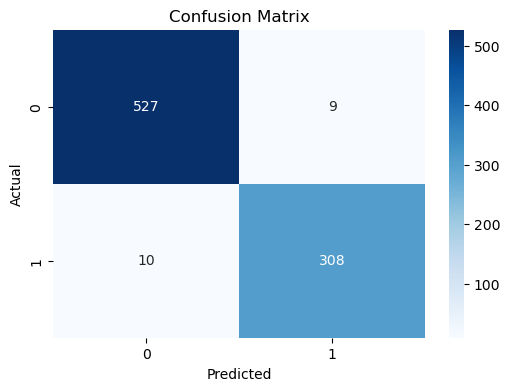

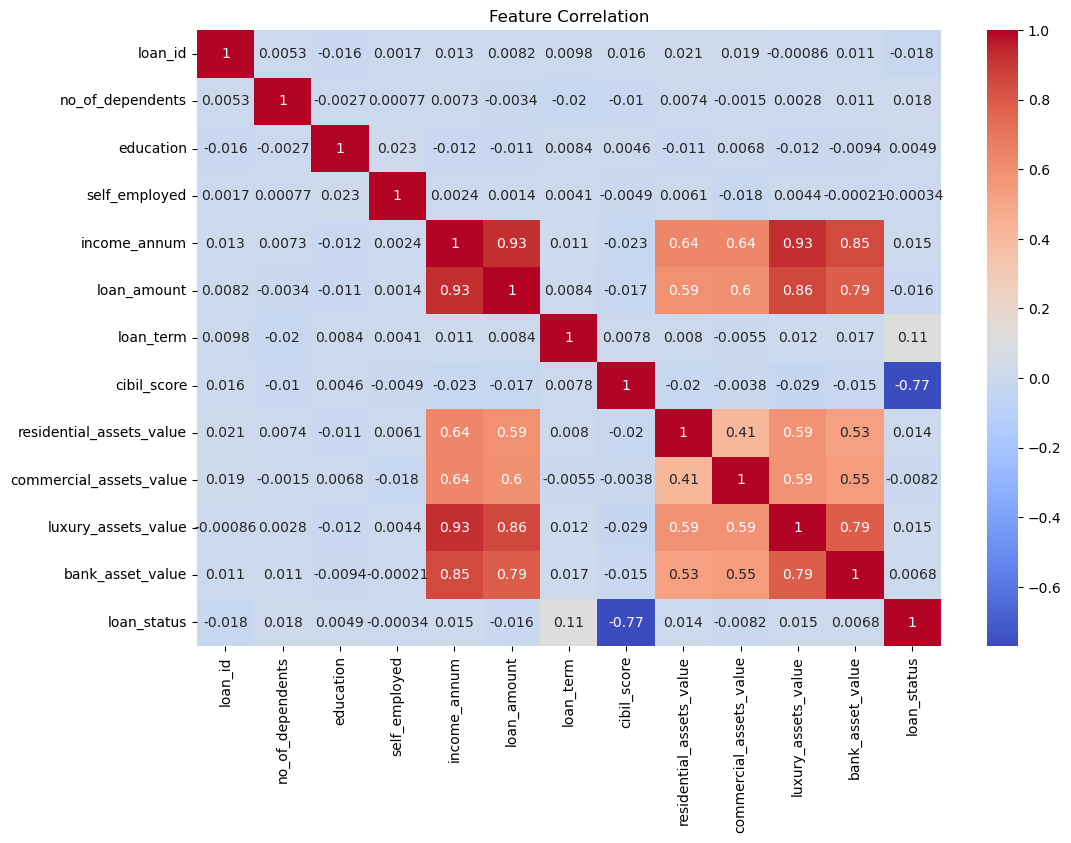


Business Insights
Average CIBIL Score of Approved Loans: 429.4680719156851
Average Income of Approved Loans: 5113825.17048977

Applicants with higher CIBIL scores
and higher annual income tend
to receive loan approvals more often.


In [1]:
# LOAN APPROVAL PREDICTION
# 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==========================================
# 2. Load Dataset
# ==========================================

df = pd.read_csv(r"G:\loan_approval_dataset.csv")

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst 5 Records:")
print(df.head())

# ==========================================
# 3. Data Exploration
# ==========================================

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
print(df.describe())

# ==========================================
# 4. Data Visualization
# ==========================================

# Loan Status Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='loan_status', data=df)
plt.title("Loan Status Distribution")
plt.show()

# Income Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['income_annum'], bins=20)
plt.title("Annual Income Distribution")
plt.show()

# CIBIL Score vs Loan Status
plt.figure(figsize=(8,5))
sns.boxplot(x='loan_status', y='cibil_score', data=df)
plt.title("CIBIL Score vs Loan Status")
plt.show()

# Loan Amount vs Loan Status
plt.figure(figsize=(8,5))
sns.boxplot(x='loan_status', y='loan_amount', data=df)
plt.title("Loan Amount vs Loan Status")
plt.show()

# ==========================================
# 5. Convert Categorical Data
# ==========================================

le = LabelEncoder()

df['education'] = le.fit_transform(df['education'])
df['self_employed'] = le.fit_transform(df['self_employed'])
df['loan_status'] = le.fit_transform(df['loan_status'])

# ==========================================
# 6. Feature Selection
# ==========================================

X = df.drop(['loan_id', 'loan_status'], axis=1)

y = df['loan_status']

# ==========================================
# 7. Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# 8. Logistic Regression
# ==========================================

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("\n===== Logistic Regression =====")

print("Accuracy:",
      accuracy_score(y_test, lr_pred))

print("\nClassification Report")
print(classification_report(y_test, lr_pred))

# ==========================================
# 9. Decision Tree
# ==========================================

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("\n===== Decision Tree =====")

print("Accuracy:",
      accuracy_score(y_test, dt_pred))

print("\nClassification Report")
print(classification_report(y_test, dt_pred))

# ==========================================
# 10. Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==========================================
# 11. Correlation Heatmap
# ==========================================

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Feature Correlation")
plt.show()

# ==========================================
# 12. Business Insights
# ==========================================

print("\nBusiness Insights")

approved = df[df['loan_status'] == 1]

print("Average CIBIL Score of Approved Loans:",
      approved['cibil_score'].mean())

print("Average Income of Approved Loans:",
      approved['income_annum'].mean())

print("\nApplicants with higher CIBIL scores")
print("and higher annual income tend")
print("to receive loan approvals more often.")